In [18]:
# Set workspace
import sys
import os
workspace_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

# Libraries

In [84]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.metrics import (
    roc_auc_score, 
    roc_curve
)
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error
)
from scipy.stats import pearsonr

---
# Get Data

In [20]:
# Get local data

utmb_race_results_df_list = []
for year in [2022, 2023, 2024, 2025]:

    utmb_year_race_results_df = pd.read_parquet(
        os.path.join("data", f"utmb_{year}_race_results.parquet")
    )
    utmb_year_race_results_df = utmb_year_race_results_df.assign(year=year)

    print(f"Data for year {year} fetched and loaded successfully")
    utmb_race_results_df_list.append(utmb_year_race_results_df)

utmb_race_results_df = pd.concat(utmb_race_results_df_list, ignore_index=True)

Data for year 2022 fetched and loaded successfully
Data for year 2023 fetched and loaded successfully
Data for year 2024 fetched and loaded successfully
Data for year 2025 fetched and loaded successfully


In [21]:
# About

print("About UTMB race results data:")
print("----------------------------------")

print("Years covered: {}".format(utmb_race_results_df["year"].unique()))
print("Number of records per year:")
for row in utmb_race_results_df["year"].value_counts().reset_index().itertuples():
    print(" - {}: {:,}".format(row[1], row[2]))

print("\nMissing data:")
for column in utmb_race_results_df.columns:
    missing_count = utmb_race_results_df[column].isnull().sum()
    if missing_count > 0:
        print(" - {}: {:,} ({:.2f}%)".format(column, missing_count, missing_count/utmb_race_results_df.shape[0] * 100))

About UTMB race results data:
----------------------------------
Years covered: [2022 2023 2024 2025]
Number of records per year:
 - 2024: 2,760
 - 2023: 2,687
 - 2022: 2,627
 - 2025: 2,489

Missing data:
 - race_category: 5,314 (50.31%)
 - runner_url: 5 (0.05%)
 - runner_overall_index: 199 (1.88%)
 - runner_diff_to_first_time: 3,592 (34.01%)
 - runner_diff_to_first_time_hours: 3,592 (34.01%)
 - race_start_time_hours: 10,563 (100.00%)
 - runner_final_status_map: 1 (0.01%)


---
# Goal: 
- What is the minimum UTMB Index such that I finish under 27h with 95% confidence? [P(finish under 27h | UTMB Index >= x) >= 0.95]
- Decomposition:
    1. The probability of finishing the race.
    2. The conditional probability of finishing under 27 hours given race completion.
- More generally: How does UTMB Index map to probability of finishing under a given cutoff time?

Thought process:
- First we need to finish 
- Then we need to finish under 27h
- P(Finish = True | UTMB index) * P(Race time < 27h | Finish = True, UTMB index) >= 0.95
    - UTMB index is not just speed, it encodes both "survival" and performance.
    - Assumption: Higher UTMB index also "covers" the DNF part (altough this is not completely true ...)
    - Finish probability increases with UTMB index? & Race time decreases with UTMB index?
- We cant just assign a race time of ex. 45h to DNF runners, because, DNF is not "just a slow time", it is a data-generating process.
- But for the runners that were broomed, we will assign a high, because they were really just a slow "time" runner. 
    - Checked the assumption and it is correct, all broomed runners have low UTMB index.
    - Will assign them race time of max in the data + 3h (this will not distort the data too much) and treat them as they finished.

Subtle issue: How UTMB index behaves inside UTMB race population.
- First we need to get into UTMB race
- My case: Will try get into UTMB race only when I think I'm ready to finish under 27h.

Additional info:
- UTMB index does not include any gender adjustment, so it allows direct comparison across genders.

In [22]:
# Keep only needed columns
utmb_race_results_sub_df = utmb_race_results_df[[
    "runner_overall_index", "runner_race_time_hours", "runner_final_status_map",  "runner_is_finisher"
]]

In [43]:
# Convert race time of DNF runners to NaN

utmb_race_results_sub_df = utmb_race_results_sub_df.assign(
    runner_race_time_hours = lambda df: np.where(df["runner_is_finisher"] == False, np.nan, df["runner_race_time_hours"])
)

print("All DNF runners have race time NaN? - {}".format(
    utmb_race_results_sub_df.query("runner_is_finisher == False")["runner_race_time_hours"].isnull().all()
))

All DNF runners have race time NaN? - True


In [24]:
# Broomed runners - Check UTMB index (it has to be low for all if our assumption is correct) and Assign DNF status & race time of max in the data + 2h.
print("Maximum UTMB index of brummed runner = {}".format(
    utmb_race_results_sub_df.query("runner_final_status_map == 'broomed'")["runner_overall_index"].max().astype(int)
))

utmb_race_results_sub_df = utmb_race_results_sub_df.assign(
    runner_race_time_hours = lambda df: np.where(df["runner_final_status_map"] == "broomed", df["runner_race_time_hours"].max() + 2, df["runner_race_time_hours"]),
    runner_is_finisher = lambda df: (np.where(df["runner_final_status_map"] == "broomed", True, df["runner_is_finisher"])).astype(int)
)

Maximum UTMB index of brummed runner = 671


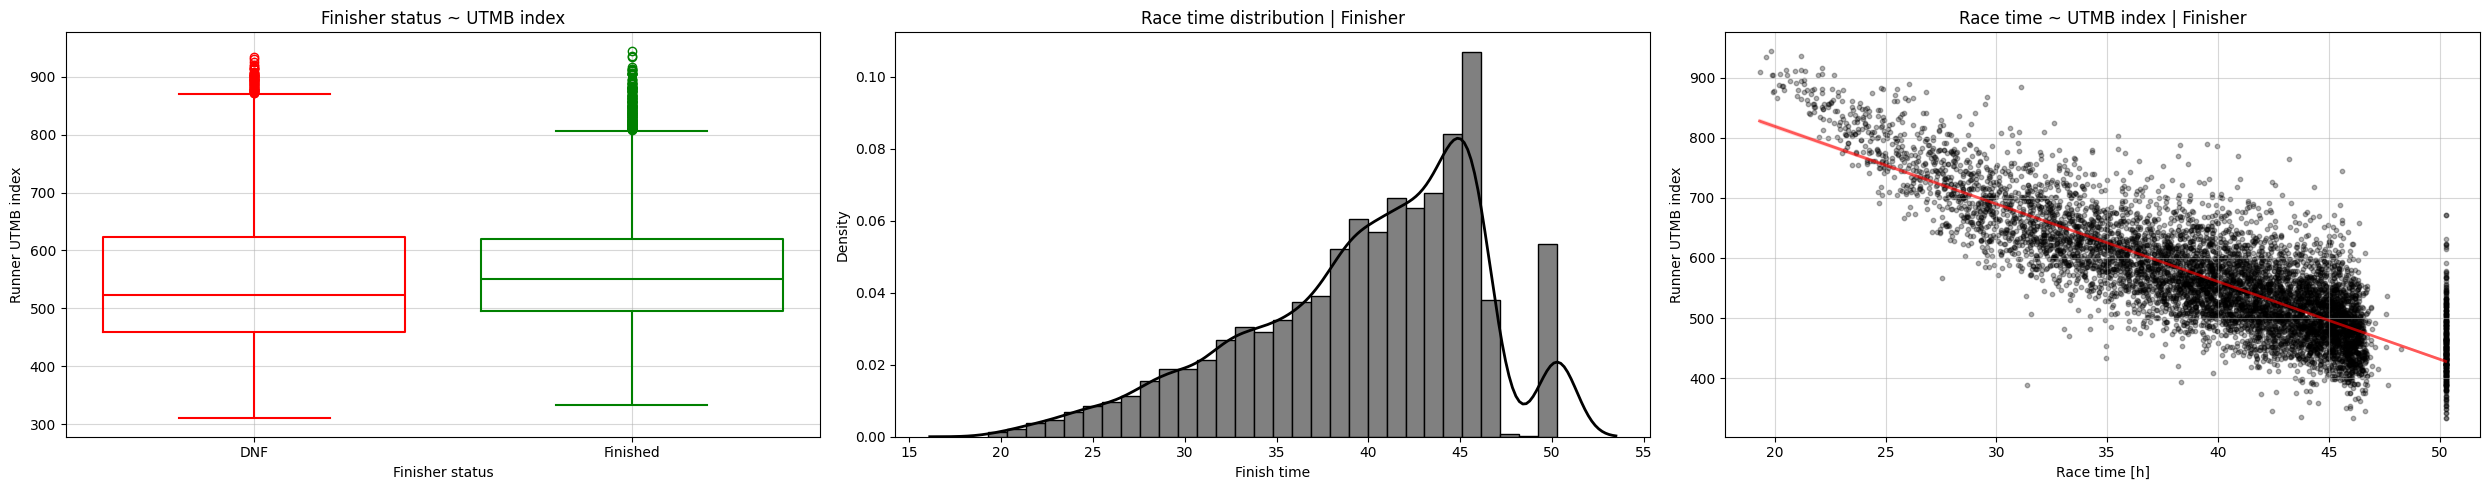

In [42]:
# Check: Finisher status ~ UTMB index & Race time ~ UTMB index
fig, ax = plt.subplots(1, 3, figsize=(25, 5))

# Finisher status
ax[0].set_title("Finisher status ~ UTMB index")
sns.boxplot(
    data=utmb_race_results_sub_df,
    x="runner_is_finisher",
    y="runner_overall_index",
    hue="runner_is_finisher", 
    palette={0: "red", 1: "green"},
    fill = False,
    dodge=False,
    ax=ax[0]
)

ax[0].set_xlabel("Finisher status")
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["DNF", "Finished"])
ax[0].legend_.remove()

# Race Time distribution
ax[1].set_title("Race time distribution | Finisher")
ax[1].hist(utmb_race_results_sub_df.query("runner_is_finisher == 1")["runner_race_time_hours"], bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(utmb_race_results_sub_df.query("runner_is_finisher == 1")["runner_race_time_hours"], ax=ax[1], color="black", linewidth=2)
ax[1].set_xlabel("Finish time")


# Race time
ax[2].set_title("Race time ~ UTMB index | Finisher")
sns.regplot(
    data=utmb_race_results_sub_df.query("runner_is_finisher == 1"),
    x="runner_race_time_hours",
    y="runner_overall_index",
    scatter_kws={"color": "black", "s": 10, "alpha": .3},
    line_kws={"color": "red", "linewidth": 2, "alpha": .6},
    ax=ax[2]
)
ax[2].set_xlabel("Race time [h]")

for i in [0,2]:
    ax[i].set_ylabel("Runner UTMB index")
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

In [38]:
# Additional about

print(" - Finishing rate: {:.2f}%".format(utmb_race_results_sub_df["runner_is_finisher"].mean() * 100))
print("     - Average UMTB index of finishers: {:.0f}".format(utmb_race_results_sub_df.query("runner_is_finisher == 1")["runner_overall_index"].mean()))
print("     - Average UMTB index of non finishers: {:.0f}".format(utmb_race_results_sub_df.query("runner_is_finisher == 0")["runner_overall_index"].mean()))

print("\n - Proportion of finishers under 27h: {:.2f}%".format((utmb_race_results_sub_df.query("runner_is_finisher == 1")["runner_race_time_hours"] <= 27).mean() * 100))
print("     - Average UTMB index of finishers under 27h: {:.0f}".format(utmb_race_results_sub_df.query("runner_is_finisher == 1 and runner_race_time_hours <= 27")["runner_overall_index"].mean()))
print("     - Lowest UTMB index of finisher under 27h: {:.0f}".format(utmb_race_results_sub_df.query("runner_is_finisher == 1 and runner_race_time_hours <= 27")["runner_overall_index"].min()))
print("     - Average UTMB index of finishers over 27h: {:.0f}".format(utmb_race_results_sub_df.query("runner_is_finisher == 1 and runner_race_time_hours > 27")["runner_overall_index"].mean()))
print("     - Highest UTMB index of finisher over 27h: {:.0f}".format(utmb_race_results_sub_df.query("runner_is_finisher == 1 and runner_race_time_hours > 27")["runner_overall_index"].max()))

 - Finishing rate: 69.86%
     - Average UMTB index of finishers: 564
     - Average UMTB index of non finishers: 553

 - Proportion of finishers under 27h: 4.31%
     - Average UTMB index of finishers under 27h: 803
     - Lowest UTMB index of finisher under 27h: 667
     - Average UTMB index of finishers over 27h: 554
     - Highest UTMB index of finisher over 27h: 884


In [ ]:
# Split data [race_time_cat] ~ ["overall", "under 27", over 27, "DNF"]
goal_time_upper_h = 27

utmb_race_time_cat_dict = {

    "overall": (
        utmb_race_results_sub_df
        .assign(race_time_cat = "overall")
        ),

    "finisher": (
        utmb_race_results_sub_df
        .query("runner_is_finisher == 1")
        .assign(race_time_cat = "finisher")
        .reset_index(drop=True)
        ),

    "dnf": (
        utmb_race_results_sub_df
        .query("runner_is_finisher == 0")
        .assign(race_time_cat = "dnf")
        .reset_index(drop=True)
        ),

    "under": (
        utmb_race_results_sub_df
        .query("runner_is_finisher == 1")
        .query("runner_race_time_hours <= @goal_time_upper_h")
        .assign(race_time_cat = "under")
        .reset_index(drop=True)
        ),

    "over": (
        utmb_race_results_sub_df
        .query("runner_is_finisher == 1")
        .query("runner_race_time_hours > @goal_time_upper_h")
        .assign(race_time_cat = "over")
        .reset_index(drop=True)
        ),
        
}

---
# Finish Probability model
- Finish ~ UTMB index

In [ ]:
# Logistic model

# Prepare for model
target = "runner_is_finisher"
features = ["runner_overall_index"]
data = utmb_race_time_cat_dict["overall"].copy()

data_model = data[[target] + features].dropna(how="any").reset_index(drop=True)
X = sm.add_constant(data_model[features])
y = data_model[target]

# Model & Predict
model = sm.Logit(y, X)
fit = model.fit(disp=False)

y_pred = fit.predict(X)
fit_summary = fit.get_prediction(X)

# Fit Metrics
fit_metrics = {
    "Pseudo R2": fit.prsquared,
    "Log-Likelihood": fit.llf,
    "AIC": fit.aic,
    "BIC": fit.bic,
    "ROC-AUC": roc_auc_score(y, y_pred)
}

# Coefficient metrics (UTMB index)
coef_features = features[0]
coef_metrics = {
    "coef": fit.params[coef_features],
    "p-value": fit.pvalues[coef_features],
    "standard error": fit.bse[coef_features],
    "confidence interval": round(fit.conf_int().loc[coef_features], 4).tolist(),
}

In [81]:
# About Logistic model
print("Fit metrics:")
print("-----------------------------")
for metric, value in fit_metrics.items():
    print("{}: {:.4f}".format(metric, value))

print("\nCoefficient metrics [UTMB index]")
print("-----------------------------")
for metric, value in coef_metrics.items():
    if metric != "confidence interval":
        print("{}: {:.4f}".format(metric, value))
    if metric == "confidence interval":
        print(f"{metric}: {coef_metrics[metric]}")

Fit metrics:
-----------------------------
Pseudo R2: 0.0018
Log-Likelihood: -6309.2514
AIC: 12622.5028
BIC: 12636.9950
ROC-AUC: 0.5612

Coefficient metrics [UTMB index]
-----------------------------
coef: 0.0010
p-value: 0.0000
standard error: 0.0002
confidence interval: [0.0006, 0.0014]


---
# Finish Time model

Finish time ~ UTMB index | Finish = True
- T = $\beta_0 + \beta_1 * \text{UTMB index} + \epsilon$ 
- $P(T \leq 27 | x, \text{Finish}) = \phi(\frac{27-\mu(x)}{\sigma})$
- 
- Assumption: $T|x ~ N(\mu, \sigma^2); \epsilon ~ N(0, \sigma^2)$
- $\mu(X) = E[T|Finish, \text{UTMB index}=x]$ - Expected race time among the finishers, with UTMB index $x$

$T = \mu(x) + \epsilon$
- We care about the residuals - variability.
    - We do not ask: What UTMB index gives average race time of 27h?
    - We ask: What UTMB index gives 95% probability of sub-27h?
- We assume: $\epsilon ~ N(0, \sigma^2)$.
    - That lets us compute probabilities analytically.
    - $P(T \leq 27 | x, \text{Finish}) = \phi(\frac{27-\mu(x)}{\sigma})$


In [85]:
# Linear model

# Prepare for model
target = "runner_race_time_hours"
features = ["runner_overall_index"]
data = utmb_race_time_cat_dict["finisher"].copy()

data_model = data[[target] + features].dropna(how="any").reset_index(drop=True)
X = sm.add_constant(data_model[features])
y = data_model[target]

# Model & Predict
model = sm.OLS(y, X)
fit = model.fit()

y_pred = fit.predict(X)
fit_summary = fit.get_prediction(X)

# Fit Metrics
fit_metrics = {
    "R2": fit.rsquared,
    "MAE": mean_absolute_error(y, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
    "Pearson correlation coefficient": pearsonr(y, y_pred)[0],
}

# Coefficient metrics (UTMB index)
coef_features = features[0]
coef_metrics = {
    "coef": fit.params[coef_features],
    "p-value": fit.pvalues[coef_features],
    "standard error": fit.bse[coef_features],
    "confidence interval": round(fit.conf_int().loc[coef_features], 4).tolist(),
}

In [87]:
# About Linear model
print("Fit metrics:")
print("-----------------------------")
for metric, value in fit_metrics.items():
    print("{}: {:.4f}".format(metric, value))

print("\nCoefficient metrics [UTMB index]")
print("-----------------------------")
for metric, value in coef_metrics.items():
    if metric != "confidence interval":
        print("{}: {:.4f}".format(metric, value))
    if metric == "confidence interval":
        print(f"{metric}: {coef_metrics[metric]}")

Fit metrics:
-----------------------------
R2: 0.6979
MAE: 2.7461
RMSE: 3.4827
Pearson correlation coefficient: 0.8354

Coefficient metrics [UTMB index]
-----------------------------
coef: -0.0540
p-value: 0.0000
standard error: 0.0004
confidence interval: [-0.0548, -0.0532]


---
# Combine the models

$P(T \leq 27 | x) = P(\text{Finish}|x) \cdot P(T \leq 27 | \text{Finish}, x)$
- We compute $P(T \leq 27 | x)$ for many UTMB index values $x$
- Finnd UTMB index $x* = \text{min}\{x: P(T \leq 27 | x) \geq 0.95\}$